# 05. Linear Regression
@Shengli (Bruce) Jiang, University of South Carolina

This notebook connects the scikit-learn workflow to the least-squares and SVD equations developed in class.

1. Fit a small exact linear model
2. Predict polymer glass-transition temperature
3. Reproduce the fit with SVD
4. Practice with a noisier polymer dataset

## Running the notebook

Run cells from top to bottom. A later cell may depend on a variable created earlier. When finished, restart the kernel and run all cells to confirm that the notebook is reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Fit a Small Exact Linear Model

Each row of $X$ is one sample. Each column is one feature. The target is constructed from

$$
y=1x_0+2x_1+3.
$$

Because these data follow the equation exactly, linear regression should recover coefficients $[1,2]$ and intercept $3$ apart from floating-point rounding.

In [2]:
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])

y = np.dot(X, np.array([1, 2])) + 3

model = LinearRegression()
model.fit(X, y)

print(model.coef_)
print(model.intercept_)
print(model.predict(np.array([[3, 5]])))

[1. 2.]
3.0000000000000018
[16.]


The trailing underscore identifies information determined during `fit`. Here, `coef_` stores the fitted feature coefficients and `intercept_` stores the fitted constant term.

## 2. Predict Polymer Glass-Transition Temperature

A polymer is a large molecule made of repeating molecular units. The glass-transition temperature, $T_g$, marks the change between a hard, glassy response and a softer, more flexible response in amorphous polymer regions.

This synthetic classroom dataset uses three structural descriptors.

| Column | Meaning |
|---|---|
| `aromatic_fraction` | Fraction of rigid aromatic groups |
| `rotatable_bond_fraction` | Fraction of flexible, rotatable bonds |
| `hbond_sites_per_repeat` | Hydrogen-bonding sites per repeat unit |
| `tg_c` | Glass-transition temperature in degrees Celsius |

The values are synthetic and are not literature measurements.

### 2.1 Load and inspect the data

In [3]:
data = pd.read_csv("polymer_tg_data.csv")

data.head()

,polymer_id,aromatic_fraction,rotatable_bond_fraction,hbond_sites_per_repeat,tg_c
0,P01,0.08,0.23,1,19.8
1,P02,0.25,0.52,0,9.8
2,P03,0.42,0.81,3,61.9
3,P04,0.59,0.34,2,141.1
4,P05,0.76,0.63,1,113.2


Each row is one polymer sample. The three descriptor columns form the feature matrix $X$, and `tg_c` forms the target vector $y$.

In [4]:
features = ["aromatic_fraction", "rotatable_bond_fraction", "hbond_sites_per_repeat"]

X = data[features].to_numpy()
y = data["tg_c"].to_numpy()

print("X shape =", X.shape)
print("y shape =", y.shape)

X shape = (36, 3)
y shape = (36,)


### 2.2 Visualize the data before fitting

Each panel shows one descriptor against $T_g$. These are marginal relationships. A multiple linear regression considers all three descriptors together.

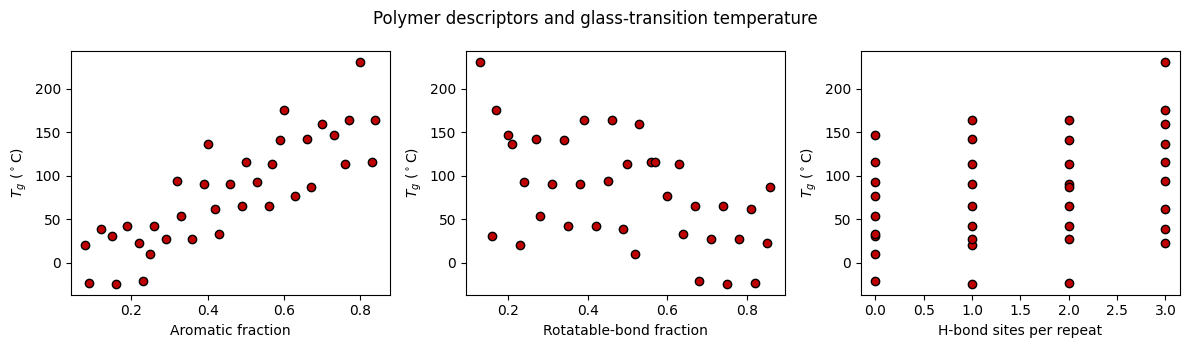

In [5]:
labels = ["Aromatic fraction", "Rotatable-bond fraction", "H-bond sites per repeat"]
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, feature, label in zip(axs, features, labels):
    ax.scatter(data[feature], y, color="#C00000", edgecolor="black")
    ax.set_xlabel(label)
    ax.set_ylabel(r"$T_g$ ($^\circ$C)")

fig.suptitle("Polymer descriptors and glass-transition temperature")
fig.tight_layout()

### 2.3 Fit with scikit-learn

The model has the form

$$
\widehat{T_g}=\theta_0+\theta_1x_1+\theta_2x_2+\theta_3x_3.
$$

In [6]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(model.intercept_)
print(model.coef_)

15.895083811721122
[ 207.97197839 -122.33678518   20.38068656]


In [7]:
coefficients = pd.DataFrame({
    "term": ["intercept", *features],
    "coefficient": [model.intercept_, *model.coef_],
})

coefficients

,term,coefficient
0,intercept,15.895084
1,aromatic_fraction,207.971978
2,rotatable_bond_fraction,-122.336785
3,hbond_sites_per_repeat,20.380687


The coefficient sign shows the fitted direction of association while the other descriptors are held fixed. Because the descriptor units differ, coefficient magnitudes should not be compared without considering those units.

### 2.4 Measure the training fit

The root-mean-square error is

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}.
$$

The same samples are used for fitting and evaluation, so this is training RMSE. It does not measure performance on new polymers.

In [8]:
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(rmse)

3.6177136730503645


A parity plot compares each true value with its prediction. Perfect predictions lie on the dashed line $\hat y=y$.

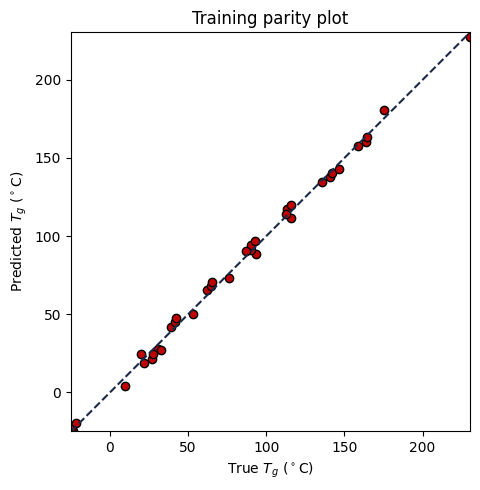

In [9]:
lower = min(y.min(), y_pred.min())
upper = max(y.max(), y_pred.max())

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(y, y_pred, color="#C00000", edgecolor="black")
ax.plot([lower, upper], [lower, upper], "--", color="#1B2A49")

ax.set_xlabel(r"True $T_g$ ($^\circ$C)")
ax.set_ylabel(r"Predicted $T_g$ ($^\circ$C)")
ax.set_title("Training parity plot")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

## 3. Reproduce the Fit with SVD

Scikit-learn hides the numerical linear algebra. We can expose it by adding a column of ones for the intercept and defining the augmented design matrix $A$.

$$
A=U\Sigma V^T,
\qquad
\hat{\theta}=V\Sigma^{-1}U^Ty,
\qquad
\hat y=A\hat{\theta}.
$$

All singular values are nonzero in this example, so $\Sigma^{-1}$ exists for the reduced SVD.

### 3.1 Build the augmented matrix and compute the SVD

In [10]:
A = np.column_stack((np.ones(X.shape[0]), X))

U, s, Vt = np.linalg.svd(A, full_matrices=False)

Sigma_inv = np.diag(1 / s)

theta = Vt.T @ Sigma_inv @ U.T @ y

y_pred = A @ theta

print(A.shape)
print(A[:4, :])
print(U.shape, s.shape, Vt.shape)

(36, 4)
[[1.   0.08 0.23 1.  ]
 [1.   0.25 0.52 0.  ]
 [1.   0.42 0.81 3.  ]
 [1.   0.59 0.34 2.  ]]
(36, 4) (4,) (4, 4)


The four columns of $A$ correspond to the intercept and the three polymer descriptors. The reduced SVD keeps only the four directions needed for this least-squares problem.

### 3.2 Inspect the coefficients and training error

In [11]:
print(theta)

[  15.89508381  207.97197839 -122.33678518   20.38068656]


In [12]:
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(rmse)

3.6177136730503654


### 3.3 Confirm that both methods agree

In [13]:
theta_sklearn = np.concatenate(([model.intercept_], model.coef_))

print(np.allclose(theta, theta_sklearn))
print(theta - theta_sklearn)

True
[-3.55271368e-14  5.68434189e-14  9.94759830e-14  1.77635684e-14]


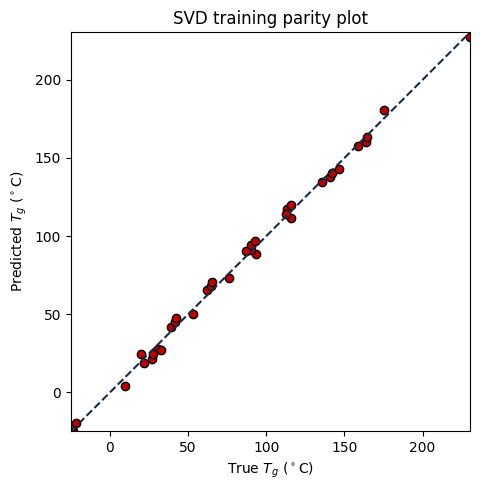

In [14]:
lower = min(y.min(), y_pred.min())
upper = max(y.max(), y_pred.max())

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y, y_pred, color="#C00000", edgecolor="black")
ax.plot([lower, upper], [lower, upper], "--", color="#1B2A49")
ax.set_xlabel(r"True $T_g$ ($^\circ$C)")
ax.set_ylabel(r"Predicted $T_g$ ($^\circ$C)")
ax.set_title("SVD training parity plot")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()

## 4. Worked Example with Noisier Polymer Data

Polymer-film tensile strength depends on both structure and processing. This synthetic dataset uses two inputs.

- **Crystallinity (%)** is the percentage of polymer in ordered, closely packed regions.
- **Draw ratio** is the final film length divided by its initial length. A draw ratio of 4 means the film was stretched to four times its initial length.

Higher crystallinity and greater chain alignment often increase tensile strength. Random noise represents material variation, measurement error, and other factors that are not included in the model.

The numerical relationships are chosen for demonstration and are not universal experimental laws.

### 4.1 Generate and Visualize the Data

In [15]:
rng = np.random.default_rng(587)

practice_data = pd.DataFrame({
    "crystallinity_pct": np.linspace(10, 70, 32),
    "draw_ratio": rng.uniform(1.0, 5.0, 32),
})

noise = rng.normal(0, 18, len(practice_data))
practice_data["tensile_strength_mpa"] = (
    12
    + 1.6 * practice_data["crystallinity_pct"]
    + 9.0 * practice_data["draw_ratio"]
    + noise
)

practice_data.head()

,crystallinity_pct,draw_ratio,tensile_strength_mpa
0,10.000000,2.208839,58.253312
1,11.935484,1.049987,40.441803
2,13.870968,4.208503,23.106102
3,15.806452,2.336832,48.466686
4,17.741935,4.871539,84.558110


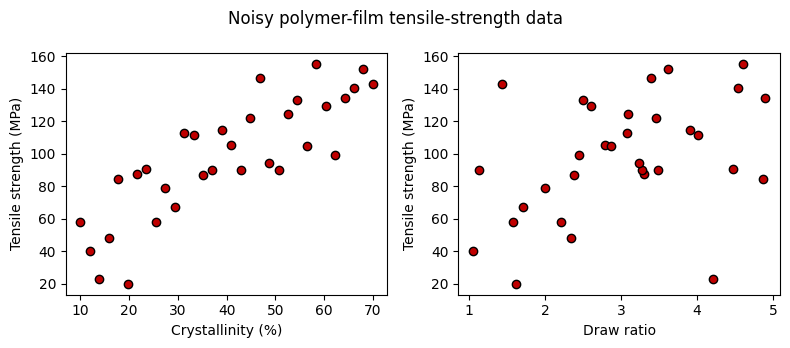

In [16]:
practice_features = ["crystallinity_pct", "draw_ratio"]
practice_labels = ["Crystallinity (%)", "Draw ratio"]

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5))

for ax, feature, label in zip(axs, practice_features, practice_labels):
    ax.scatter(
        practice_data[feature],
        practice_data["tensile_strength_mpa"],
        color="#C00000",
        edgecolor="black",
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Tensile strength (MPa)")

fig.suptitle("Noisy polymer-film tensile-strength data")
fig.tight_layout()

### 4.2 Fit with Scikit-Learn

Use crystallinity and draw ratio to predict tensile strength. All samples are used for fitting.

In [17]:
practice_features = ["crystallinity_pct", "draw_ratio"]

X_practice = practice_data[practice_features].to_numpy()
y_practice = practice_data["tensile_strength_mpa"].to_numpy()

practice_reg = LinearRegression()
practice_reg.fit(X_practice, y_practice)

print("Intercept (MPa)", practice_reg.intercept_)
print("Crystallinity coefficient (MPa per percentage point)", practice_reg.coef_[0])
print("Draw-ratio coefficient (MPa per unit draw ratio)", practice_reg.coef_[1])

Intercept (MPa) 7.992208796590788
Crystallinity coefficient (MPa per percentage point) 1.5658911931805901
Draw-ratio coefficient (MPa per unit draw ratio) 9.130394185791525


### 4.3 Evaluate the Training Fit

The training RMSE measures the typical prediction error on the same samples used to fit the model. The parity plot compares each measured value with its fitted value.

Training RMSE (MPa) 17.16117825376837


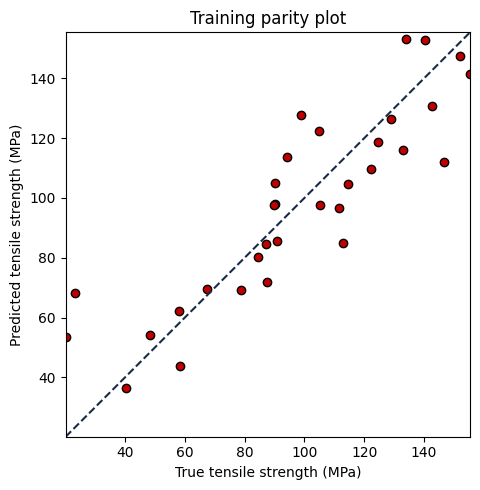

In [18]:
y_practice_pred = practice_reg.predict(X_practice)

practice_rmse = np.sqrt(np.mean((y_practice_pred - y_practice) ** 2))
print("Training RMSE (MPa)", practice_rmse)

lower = min(y_practice.min(), y_practice_pred.min())
upper = max(y_practice.max(), y_practice_pred.max())

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_practice, y_practice_pred, color="#C00000", edgecolor="black")
ax.plot([lower, upper], [lower, upper], "--", color="#1B2A49")
ax.set_xlabel("True tensile strength (MPa)")
ax.set_ylabel("Predicted tensile strength (MPa)")
ax.set_title("Training parity plot")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()

### 4.4 Reproduce the Fit with SVD

The intercept column is added explicitly. The SVD solution follows $\hat{\theta}=V\Sigma^{-1}U^Ty$.

In [19]:
A_practice = np.column_stack((np.ones(X_practice.shape[0]), X_practice))

U_practice, s_practice, Vt_practice = np.linalg.svd(
    A_practice,
    full_matrices=False,
)

Sigma_inv_practice = np.diag(1 / s_practice)

theta_practice = (
    Vt_practice.T
    @ Sigma_inv_practice
    @ U_practice.T
    @ y_practice
)

theta_sklearn_practice = np.concatenate(
    ([practice_reg.intercept_], practice_reg.coef_)
)

print("SVD parameters", theta_practice)
print("Scikit-learn parameters", theta_sklearn_practice)
print("Solutions match", np.allclose(theta_practice, theta_sklearn_practice))

SVD parameters [7.9922088  1.56589119 9.13039419]
Scikit-learn parameters [7.9922088  1.56589119 9.13039419]
Solutions match True
